### 第3章 Pandas 绘图
- `Pandas` 是面板数据(Panel Data)和Python数据分析(Python Data Analysis)的简称
- Series 对象是带索引的一维数组结构，表示一列数据
    - `pandas.Series(data, index=index)`
        - `data`：数据，支持列表、字典、NumPy数组、标量值
        - `index`：行标签索引，默认为整数序列（0 ~ data长度-1）
- DataFrame 对象是带索引的二维数组结构，表示表格型数据，包括行和列
    - `pandas.DataFrame(data, index, columns, dtype, copy)`
        - `data`：数据，可以是列表、字典、NumPy数组、Series对象等
        - `index`：行标签索引
        - `columns`：列标签索引
        - `dtype`：每一列的数据类型
            - `object`：通用数据类型，类似于Python的字典
            - `int64`：整型数据
            - `float64`：浮点型数据 
            - `bool`：布尔型数据类型，True或False
            - `datetime64`：时间戳数据类型，精确到纳秒，对应`datetime64[ns]`
            - `category`：分类数据类型，类似于Python的集合
            - `timedelta64[ns]`：时间差类型，精确到纳秒
        - `copy`：是否复制数据

In [2]:
# 导入pandas模块
import pandas as pd

# 使用列表创建Series对象
s1 = pd.Series([1, 2, 3])
print(s1)
# 使用字典创建Series对象
s2 = pd.Series({"A": 1, "B": 2, "C": 3})
print(s2)

0    1
1    2
2    3
dtype: int64
A    1
B    2
C    3
dtype: int64


In [ ]:
import pandas as pd

# 解决数据输出时列不对齐的问题
pd.set_option("display.unicode.east_asian_width", True) # 启用东亚字符宽度
# 创建数据
df = pd.DataFrame(
    {
        "姓名": ["甲", "乙", "丙"],
        "语文": [110, 105, 109],
        "数学": [105, 88, 120],
        "英语": [99, 115, 130],
    }
)
print(df)

  姓名  语文  数学  英语
0   甲   110   105    99
1   乙   105    88   115
2   丙   109   120   130


#### 实现数据可视化
- `DataFrame.plot()` 函数用于绘制 Series 对象或 DataFrame 对象的图形
##### 绘制折线图 

   阅读  点赞  收藏
0   209   100    23
1   172    79    18
2   169    90     7
3   185     8     0
4   156     0     0


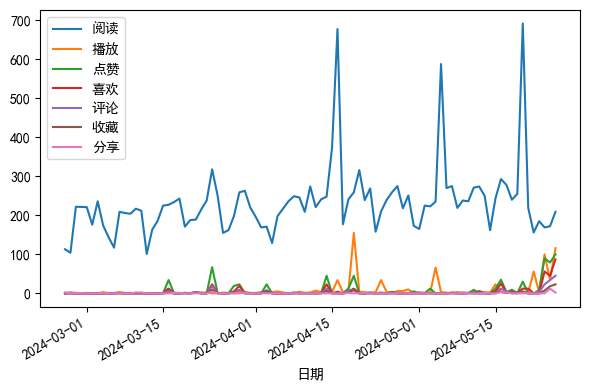

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置数据显示的编码格式为东亚宽度，以使列对齐
pd.set_option("display.unicode.east_asian_width", True)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题

# 读取Excel文件
df = pd.read_excel("../datas/日报表.xlsx")
# 抽取“阅读”、“点赞”和“收藏”列
df_chosen = df[["阅读", "点赞", "收藏"]]
print(df_chosen.head())    # 输出前5条数据

df.plot(
    x="日期",       # 设置x轴为日期
    kind="line",    # 图表类型
    legend=True,    # 显示图例
    figsize=(6, 4), # 画布大小
)  
plt.tight_layout()  # 解决图形元素显示不全的问题
plt.show()  # 显示图表

##### 绘制柱形图

  月份  总店  二道分店  南关分店  朝阳分店
0  1月    20        45        28        55
1  2月    14        34        38        34
2  3月    23        56        32        28
3  4月    34        38        43        36
4  5月    56        49        26        48
5  6月    28        60        45        55


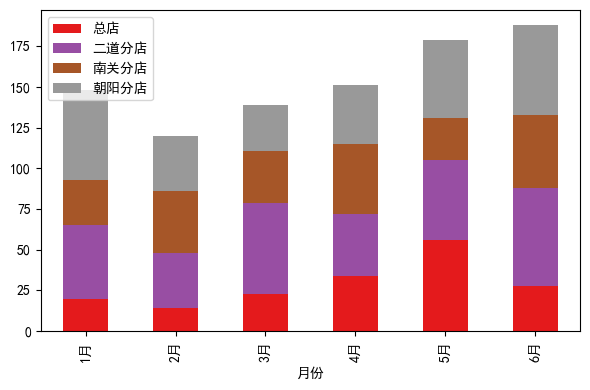

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决数据输出时列不对齐的问题
pd.set_option("display.unicode.east_asian_width", True)
# 创建DataFrame数据
df = pd.DataFrame(
    {
        "月份": ["1月", "2月", "3月", "4月", "5月", "6月"],
        "总店": [20, 14, 23, 34, 56, 28],
        "二道分店": [45, 34, 56, 38, 49, 60],
        "南关分店": [28, 38, 32, 43, 26, 45],
        "朝阳分店": [55, 34, 28, 36, 48, 55],
    }
)
print(df)

plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码问题
# 绘制多柱形图
df.plot(
    x="月份",
    kind="bar",     # 图表类型
    legend=True,    # 显示图例
    stacked=True,   # 堆叠柱形图, 默认False
    colormap="Set3",   # 配色方案: "Paired", "Accent", "Dark2", "Set1", "Set2", "Set3"
    figsize=(6, 4), # 画布大小
)  
plt.tight_layout()
plt.show()

##### 绘制饼图

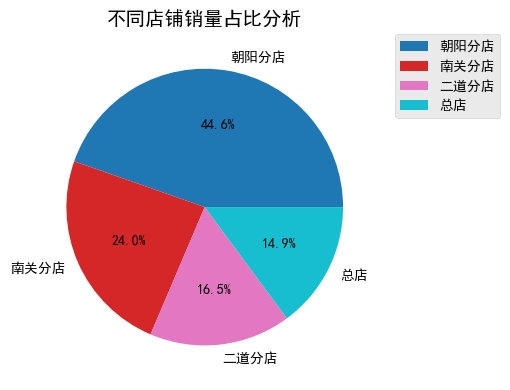

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决数据输出时列不对齐的问题
pd.set_option("display.unicode.east_asian_width", True)
# 创建DataFrame数据
df = pd.DataFrame(
    {
        "月份": ["1月", "2月", "3月", "1月", "2月", "3月", "1月", "2月", "3月", "1月", "2月", "3月"],
        "店铺名称": ["总店", "总店", "总店", 
                    "南关分店", "南关分店", "南关分店",
                    "二道分店", "二道分店", "二道分店",
                    "朝阳分店", "朝阳分店", "朝阳分店"],
        "销量": [50, 88, 42, 64, 128, 98, 34, 99, 67, 52, 255, 233],
    }
)
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码问题
# 统计结果按销量降序排序绘制饼形图
df.groupby("店铺名称").sum().sort_values(by="销量", ascending=False).plot(
    y="销量",           # y轴数据
    kind="pie",         # 饼形图
    autopct="%.1f%%",   # 百分比保留小数点后1位
    colormap="tab10",   # 每块饼图的颜色
    figsize=(6, 4),      # 设置图表大小
)  

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)  # 设置图例
plt.title("不同店铺销量占比分析", fontsize=14, fontweight="bold")  # 图表标题
plt.tight_layout()
plt.show()

##### 绘制直方图
- `DataFrame.hist(column=None, by=None, grid=True, xlabelsize=None, xrot=None, ylabelsize=None, yrot=None, ax=None, sharex=False, sharey=False, figsize=None, layout=None, bins=10, backend=None, legend=False, **kwargs)` 
    - `column`：字符串或字符串构成的列表，指定直方图分析的列
    - `by`：字符串或数组，指定列进行分组，实现多组合直方图分析
    - `grid`：是否显示网格线，默认为True
    - `xlabelsize`, `ylabelsize`：X 轴或 Y 轴标签字体大小，默认为None
    - `xrot`, `yrot`：X 轴或 Y 轴标签旋转角度，默认为None
    - `ax`：matplotlib.axes.Axes 对象，默认为None
    - `sharex`, `sharey`：是否共享X轴或Y轴，默认为False
    - `figsize`：图形大小，默认为None
    - `layout`：图形布局，默认为None
    - `bins`：直方图被分割后的区间，默认为10
    - `backend`：绘图后端，默认为None
    - `legend`：是否显示图例，默认为False
    - `**kwargs`：其他关键字参数，传递给matplotlib绘图函数

   序号      班级    姓名  得分
0   1  高二年级1班  mr01  84
1   2  高二年级1班  mr02  82
2   3  高二年级1班  mr03  78
3   4  高二年级1班  mr04  76
4   5  高二年级1班  mr05  76


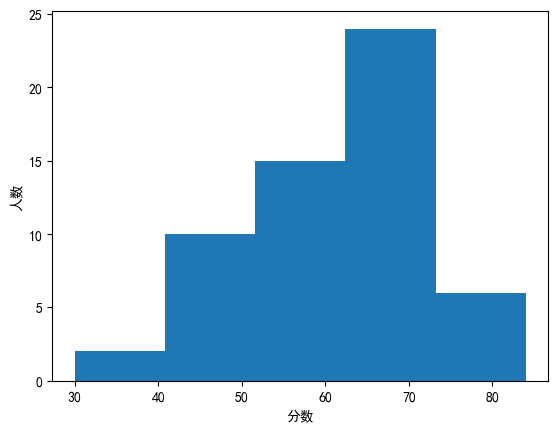

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码


df = pd.read_csv("../datas/英语成绩报告.csv", encoding="gbk")  # 读取csv文件（encoding编码格式为gbk）
print(df.head())  # 输出前5条数据
# 绘制“得分”直方图，分为5个区间，不显示网格
df["得分"].hist(bins=5, grid=False)
# xy轴标题
plt.xlabel("分数")
plt.ylabel("人数")
# 显示图表
plt.show()

##### 绘制散点图

      姓名 性别  年龄 民族  学历    薪资
0  mr001  男  47  汉  本科  7800
1  mr002  女  33  汉  本科  9000
2  mr003  女  27  汉  本科  6790
3  mr004  女  34  汉  本科  6500
4  mr005  女  30  蒙  大专  4500


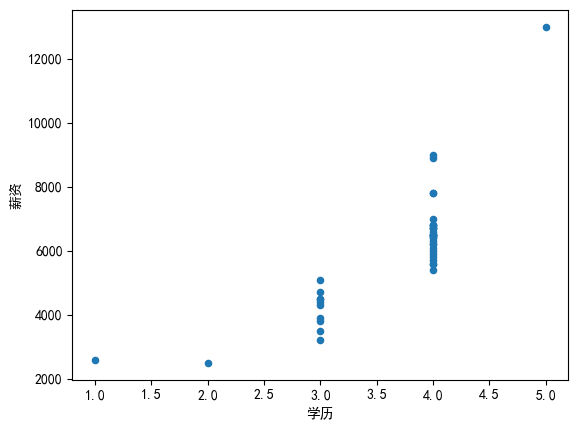

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# 解决中文乱码
plt.rcParams["font.sans-serif"] = ["SimHei"]

df = pd.read_excel("../datas/data2.xlsx")  # 读取Excel文件
print(df.head())    # 输出前5条数据
# 创建“学历”字典
xl_mapping = {"硕士": 5, "本科": 4, "大专": 3, "高中": 2, "中专": 1}
# 将“学历”映射为数字
df["学历"] = df["学历"].map(xl_mapping)
# 绘制学历与薪资散点图
df.plot(x="学历", y="薪资", kind="scatter")
# 显示图表
plt.show()


##### 绘制箱线图
- `DataFrame.boxplot(column=None, by=None, ax=None, fontsize=None, rot=0, grid=None, figsize=None, layout=None, return_type=None,  **kwds)` 
    - `column`：字符串或字符串构成的列表，指定直方图分析的列
    - `by`：字符串或数组，通过指定`by='column'`进行多组合箱线图分析
    - `xlabelsize`, `ylabelsize`：X 轴或 Y 轴标签字体大小，默认为None
    - `xrot`, `yrot`：X 轴或 Y 轴标签旋转角度，默认为None
    - `ax`：matplotlib.axes.Axes 对象
    - `fontsize`：箱线图坐标轴的字体大小
    - `rot`：箱线图坐标轴的旋转角度，默认为0
    - `grid`：是否显示网格线，默认为True
    - `figsize`：箱线图的画布大小
    - `layout`：必须配合 by 参数使用
    - `return_type`：返回对象的类型，默认为None，可设置的值有'axes', 'dict'和'both'；当与参数 by 一起使用时，返回的对象为 Series 或 array 数组
    - 返回值：当`return_type='dict'`时，结果为字典，字典索引为固定的'whiskers', 'caps', 'boxes', 'fliers'或'means'

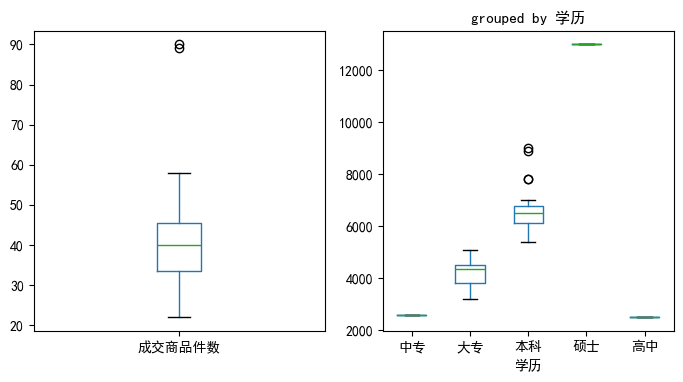

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码

# 读取Excel文件，按成交商品数分析异常数据
df = pd.read_excel("../datas/all.xlsx")
# 筛选数据：df.shape=(1437, 6), df1.shape=(31, 6)
df1 = df[df["商品名称"] == "Python数据分析从入门到实践（全彩版）"]
# 绘制箱形图
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
df1.boxplot(column="成交商品件数", grid=False, ax=axes[0])


# 按学历分析薪资异常数据
df2 = pd.read_excel("../datas/data2.xlsx")
# 绘制箱形图：df.shape=(43, 6)
df2.boxplot(column="薪资", by="学历", grid=False, ax=axes[1])

# 删除中央的 groupby 标题
fig.suptitle("")  # 清空中央标题
# 设置右侧子图标题
axes[1].set_title("grouped by 学历", fontsize=11)

# 显示图表
plt.show()

#### “动物森友会”季节性数据可视化

       Temperature(℃)  Rainy Days  Insects  Fish
Month                                           
1            5.000000         5.4     31.0  35.0
2           13.109612        11.2     37.0  31.0
3           18.644480        19.2     45.0  26.0
4           19.847322        18.0     29.0  30.0
5           16.336244        14.3     32.0  15.0
6            9.225988        14.3     20.0  16.0
7            9.225988         9.0     20.0  28.0
8           16.336244         9.8     21.0  21.0
9           19.847322         4.0     23.0  17.0
10          18.644480         6.8     36.0  27.0
11          13.109612         9.0     39.0  33.0
12           5.000000         7.2     38.0  32.0


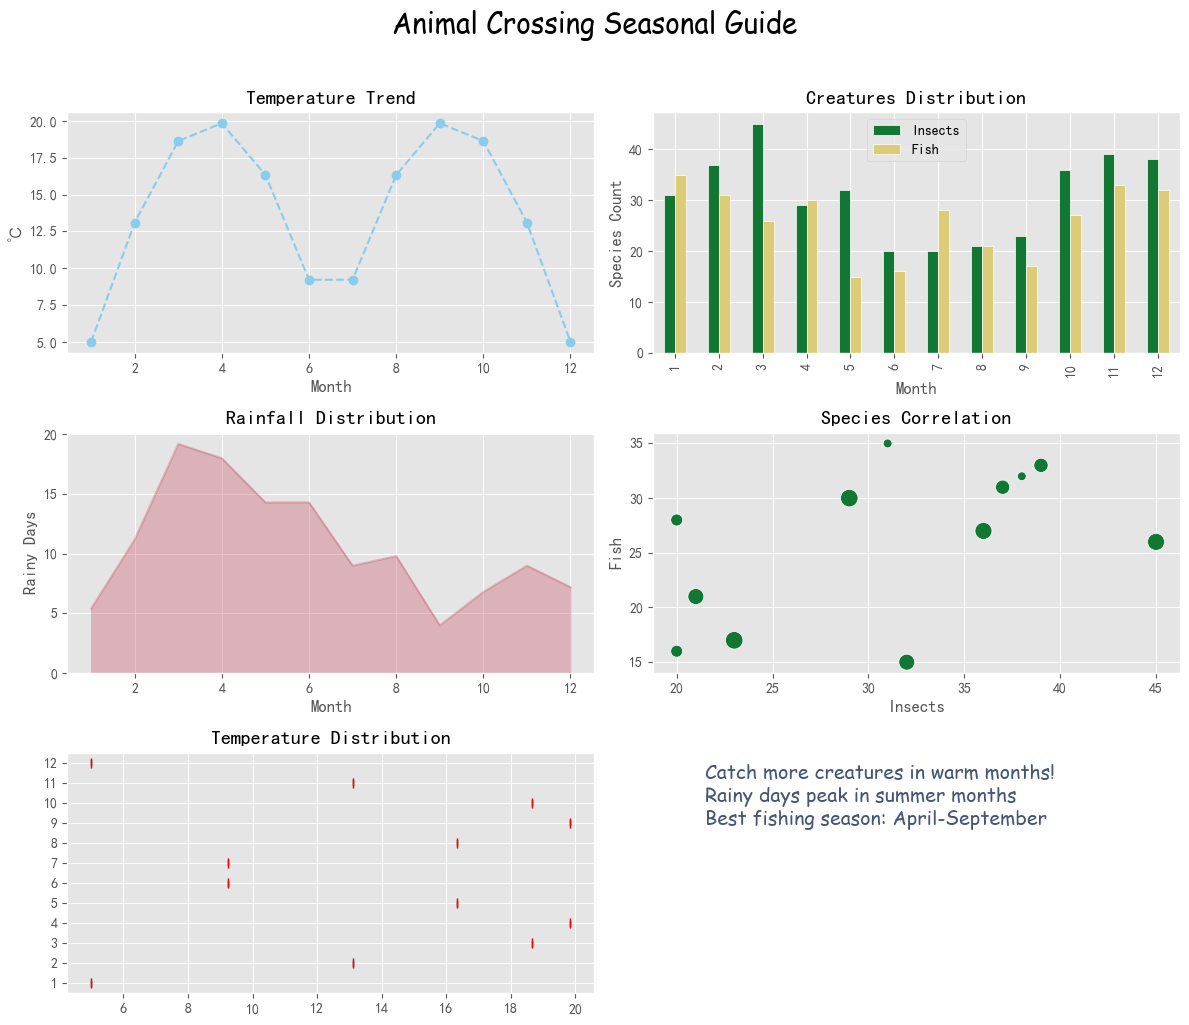

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 生成模拟数据
np.random.seed(2026)    # 设置随机种子以确保结果可重复
months = np.arange(1, 13)  # 月份从1到12
temperature = 5 + 15 * np.abs(np.sin(np.linspace(0, 2*np.pi, num=12)))  # 使用正弦函数生成温度数据
rain_days = np.random.randint(8, 18, 12) * np.array([0.6, 0.8, 1.2, 1.5, 1.3, 1.1, 0.9, 0.7, 0.5, 0.4, 0.6, 0.9])   # 生成降雨天数数据（每月降雨天数随月份变化）
insects = np.clip(np.round(30 + 10*np.sin(months/1.5) + np.random.normal(0, 3, 12)), 20, 45)  # 生成昆虫数量数据（介于20到45之间）
fish = np.clip(np.round(25 + 8*np.cos(months/2) + np.random.normal(0, 4, 12)), 15, 40)  # 生成鱼类数量数据（介于15到40之间）

df = pd.DataFrame(
    {
        "Month": months,
        "Temperature(℃)": temperature,
        "Rainy Days": rain_days,
        "Insects": insects,
        "Fish": fish
    }
).set_index("Month")    # 将月份设置为索引
print(df)

# 设置森友会主题样式
plt.style.use('ggplot')
colors = ['#88CCEE', '#117733', '#DDCC77', '#CC6677']   # 森友会配色
# 创建组合列表
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
plt.suptitle('Animal Crossing Seasonal Guide', fontsize=20, y=1.02, fontfamily='cursive')   

# 1. 温度趋势折线图
df['Temperature(℃)'].plot(
    ax=axes[0, 0], 
    marker='o', 
    color=colors[0], 
    title='Temperature Trend', 
    ylabel='℃',
    grid=True,
    linestyle='--'
)
# 2. 生物分布柱状图
df[['Insects', 'Fish']].plot(
    ax=axes[0, 1], 
    kind='bar', 
    color=[colors[1], colors[2]], 
    title='Creatures Distribution', 
    ylabel='Species Count',
    edgecolor='white'
)
# 3. 降雨分布面积图
df['Rainy Days'].plot(
    ax=axes[1, 0], 
    kind='area', 
    color=colors[3], 
    alpha=0.4, 
    title='Rainfall Distribution', 
    ylabel='Rainy Days',
    grid=True,
)
# 4. 物种相关性散点图
df.plot(
    ax=axes[1, 1], 
    kind='scatter', 
    x='Insects',
    y='Fish',
    color=colors[1],
    s=df['Temperature(℃)'] * 8,     # 根据温度大小调整点的大小
    title='Species Correlation',
    edgecolor='w'
)
# 5. 温度分布箱线图
df[['Temperature(℃)']].T.plot(
    ax=axes[2, 0], 
    kind='box', 
    color=dict(boxes=colors[0], whiskers=colors[1], medians='red'),
    title='Temperature Distribution',
    patch_artist=True,              # 填充箱体
    vert=False,                     # 水平箱线图
)

# 添加趣味注释
axes[2, 1].axis('off')
axes[2, 1].text(0.1, 0.7,
                "Catch more creatures in warm months! \n"
                "Rainy days peak in summer months \n"
                "Best fishing season: April-September",
                fontsize=14,
                fontfamily='cursive',
                color='#445577')
plt.tight_layout()
plt.savefig('animal_crossing_charts.png', bbox_inches='tight')  # 裁剪掉图表周围的空白区域并保存图片
plt.show()